In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load training dataset

df = pd.read_csv("train.csv", index_col = "Id")

In [4]:
# Data overview

print("df shape: ", df.shape)
print("Missing values: \n", df.isnull().sum().sort_values(ascending=False))
print("Data types: \n", df.dtypes.value_counts())
df.head()


df shape:  (1460, 80)
Missing values: 
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 80, dtype: int64
Data types: 
 str        43
int64      34
float64     3
Name: count, dtype: int64


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


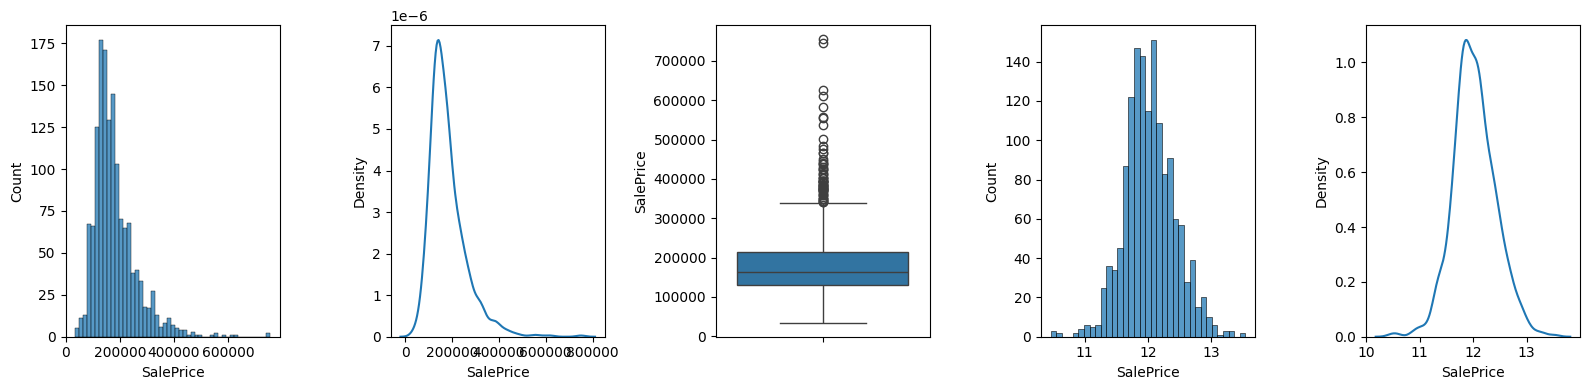

In [5]:
# Target variable exploration

fig, axes = plt.subplots(ncols=5, figsize = (16, 4)) 

sns.histplot(df["SalePrice"], ax=axes[0])
sns.kdeplot(df["SalePrice"], ax=axes[1])
sns.boxplot(df["SalePrice"], ax=axes[2])
sns.histplot(np.log1p(df["SalePrice"]), ax=axes[3])
sns.kdeplot(np.log1p(df["SalePrice"]), ax=axes[4])

plt.tight_layout()
plt.show()

Since house prices appear normally distributed under log transform, the new target variable will be log(SalePrice), to be convert back to SalePrice after prediction.

In [6]:
# Missing value analysis

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
# Fill missing with None

cols_to_fill_with_NA = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageType", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtFinType1", "Electrical"]

df[cols_to_fill_with_NA] = df[cols_to_fill_with_NA].fillna("None")

In [8]:
# Fill missing lot frontage with 0

df["LotFrontage"] = df["LotFrontage"].fillna(0)

In [9]:
# Fill MasVnrArea by median of MasVnrType

df['MasVnrArea'] = df['MasVnrArea'].fillna(
    df.groupby('MasVnrType')['MasVnrArea'].transform('median')
)

In [10]:
# Fill garage year built and finished both as 0, to later create garage age

df[["GarageYrBlt", "GarageFinish"]] = df[["GarageYrBlt", "GarageFinish"]].fillna(0)

In [19]:
# Numeric feature distrubtion

numeric_cols = df.select_dtypes(np.number).columns.drop("SalePrice")

print("Numeric columns: ", len(numeric_cols))

Numeric columns:  36


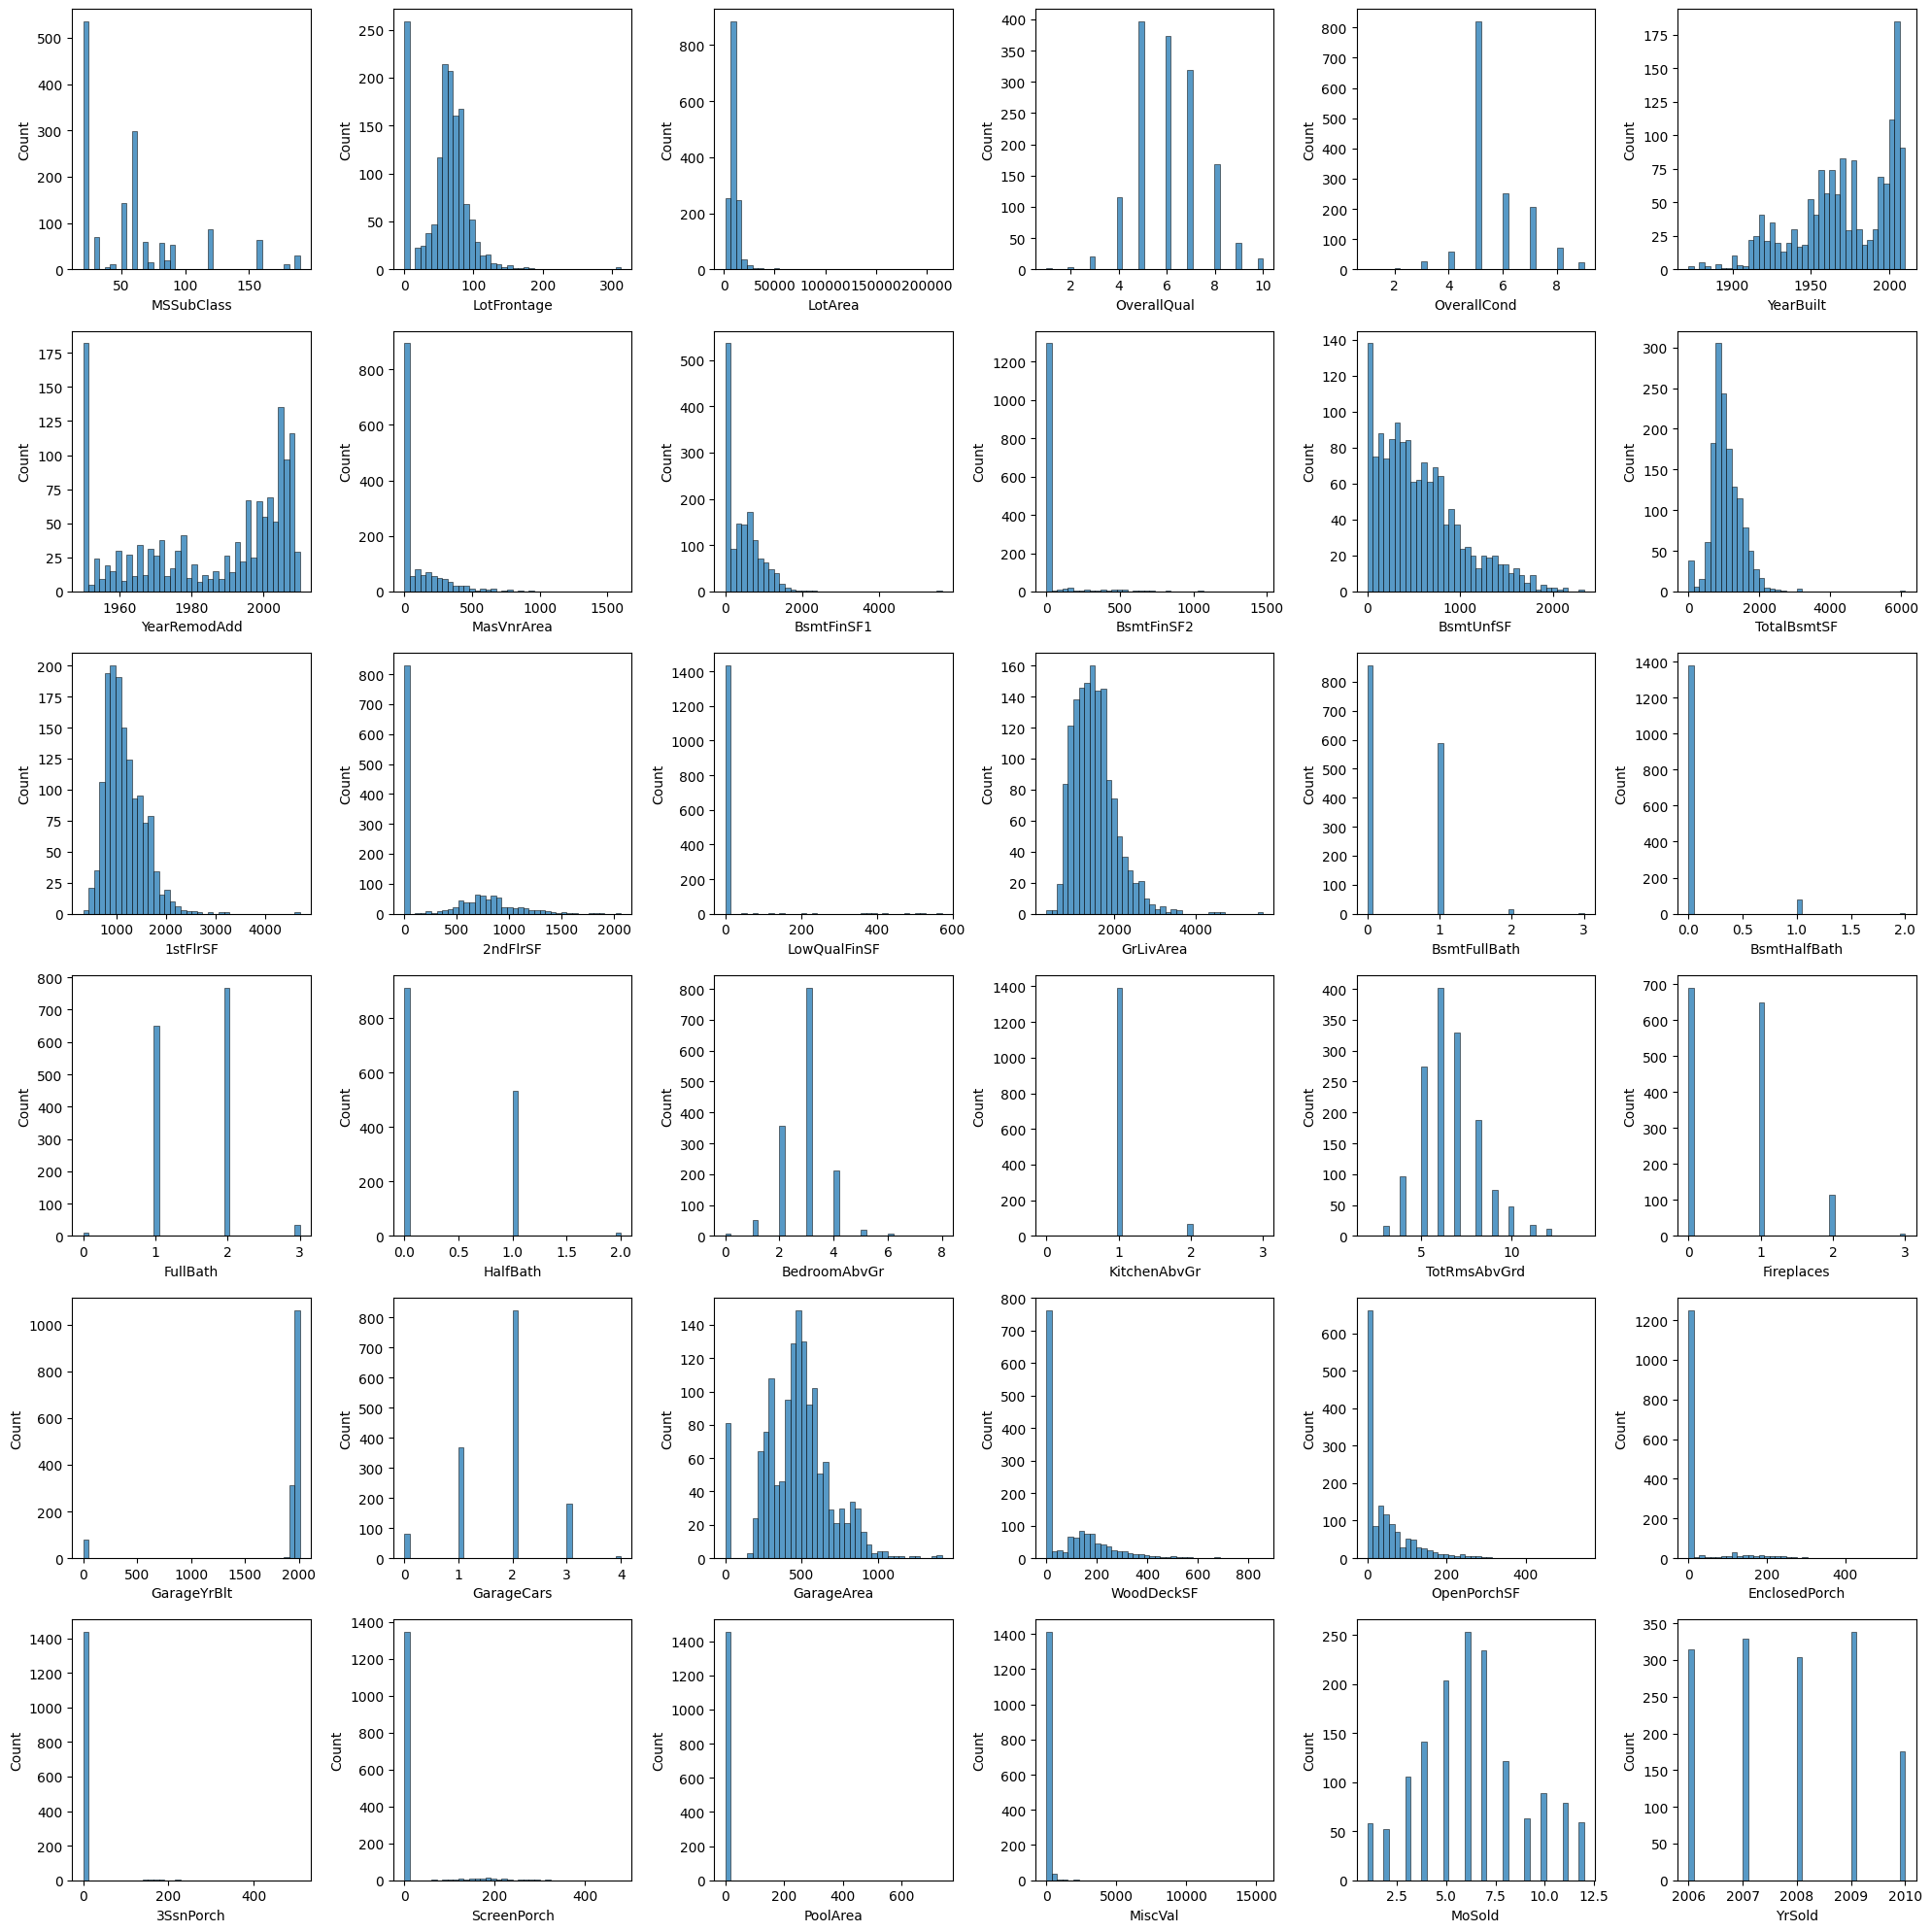

In [20]:
# Plot numeric feature distributions in 6 x 6 grid (exclude SalePrice)

fig, axes = plt.subplots(6, 6, sharex = False, sharey = False, figsize = (20, 20))

# Make looping easier
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins = 40, ax = axes[i])

plt.tight_layout()
plt.show()

In [17]:
# Identify most skewed numeric features

df.select_dtypes(include="number").skew().sort_values(ascending=False)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
LotFrontage       0.267822
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -3.869501
d

In [21]:
# Feature log transforms

features_to_log = ["LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "LowQualFinSF", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "MiscVal"]

for col in features_to_log:
    df[col] = np.log1p(df[col])

In [22]:
# Feature convert to binary

features_to_binary = ["2ndFlrSF", "3SsnPorch", "ScreenPorch", "PoolArea"]

for col in features_to_binary:
    df[col] = df[col] > 0

In [23]:
df.select_dtypes(include="number").skew().sort_values(ascending=False)

LowQualFinSF     7.460317
MiscVal          5.170704
KitchenAbvGr     4.488397
BsmtHalfBath     4.103403
BsmtFinSF2       2.523694
EnclosedPorch    2.112275
SalePrice        1.882876
TotalBsmtSF      1.524255
MSSubClass       1.407657
1stFlrSF         1.376757
GrLivArea        1.366560
BsmtUnfSF        0.920268
OverallCond      0.693067
TotRmsAbvGrd     0.676341
HalfBath         0.675897
Fireplaces       0.649565
BsmtFullBath     0.596067
MasVnrArea       0.503532
LotFrontage      0.267822
OverallQual      0.216944
MoSold           0.212053
BedroomAbvGr     0.211790
GarageArea       0.179981
WoodDeckSF       0.153537
YrSold           0.096269
FullBath         0.036562
OpenPorchSF     -0.023397
LotArea         -0.137404
GarageCars      -0.342549
YearRemodAdd    -0.503562
YearBuilt       -0.613461
BsmtFinSF1      -0.618410
GarageYrBlt     -3.869501
dtype: float64

In [ ]:
# Create total_baths feature